# ML Basics & Linear Regression Assignment

## Problem Statement

You are working as a Data Analyst for a real estate company. The objective is to predict house prices based on various housing features such as crime rate, number of rooms, property tax, distance from employment centers, and other factors. The assignment involves performing Exploratory Data Analysis (EDA), building a Linear Regression model, evaluating its performance, and interpreting the results.

## Q1. What is Machine Learning? Explain the main types of Machine Learning with examples.

#### Answer :

Machine Learning (ML) is a branch of Artificial Intelligence (AI) that enables computers to learn patterns from data and make predictions or decisions without being explicitly programmed.

### Types of Machine Learning

### 1. Supervised Learning
In supervised learning, the model is trained using labeled data, where both the input and the correct output are known.

**Examples:**
- House Price Prediction
- Email Spam Detection
- Student Marks Prediction

### 2. Unsupervised Learning
In unsupervised learning, the model works with unlabeled data and tries to discover hidden patterns or groups.

**Examples:**
- Customer Segmentation
- Market Basket Analysis
- Clustering of Similar Products

### 3. Reinforcement Learning
In reinforcement learning, an agent learns by interacting with its environment and receives rewards or penalties based on its actions.

**Examples:**
- Self-driving Cars
- Robotics
- Game Playing (Chess, Go)

## Q2. What is Supervised Learning? Explain the difference between Regression and Classification.

#### Answer :

Supervised Learning is a type of Machine Learning in which the model learns from labeled data. The goal is to predict the output for new unseen data.

### Difference between Regression and Classification

| Regression | Classification |
|------------|----------------|
| Predicts continuous values. | Predicts categorical values. |
| Output is numerical. | Output is a class or category. |
| Used for price, salary, temperature prediction. | Used for spam detection, disease prediction, sentiment analysis. |
| Example: Predicting house prices. | Example: Predicting whether an email is spam or not. |
|Regression answers **"How much?"** | while Classification answers **"Which category?"** |

## Q3. What is Linear Regression? Write the Linear Regression equation and explain intercept and coefficient.

#### Answer :

Linear Regression is a supervised learning algorithm used to predict a continuous dependent variable based on one or more independent variables.

The Linear Regression equation is:

**Y = β₀ + β₁X₁ + β₂X₂ + ... + βₙXₙ**

where,

- **Y** = Predicted value (Dependent variable)
- **β₀** = Intercept
- **β₁, β₂, ... βₙ** = Coefficients
- **X₁, X₂, ... Xₙ** = Independent variables

### Intercept (β₀)

The intercept is the predicted value of Y when all independent variables are equal to zero.

### Coefficient (β)

A coefficient represents the expected change in the dependent variable for a one-unit increase in the corresponding independent variable, while keeping all other variables constant.

## Q4. Explain the following evaluation metrics used in Linear Regression:

- SSE
- MSE
- RMSE
- R² Score
- Adjusted R²

#### Answer :

### 1. SSE (Sum of Squared Errors)

SSE measures the total squared difference between the actual values and the predicted values.

Formula:

SSE = Σ(y − ŷ)²

A smaller SSE indicates a better model.

---

### 2. MSE (Mean Squared Error)

MSE is the average of the squared errors.

Formula:

MSE = SSE / n

Lower MSE indicates better prediction accuracy.

---

### 3. RMSE (Root Mean Squared Error)

RMSE is the square root of MSE.

Formula:

RMSE = √MSE

RMSE is expressed in the same unit as the target variable, making it easier to interpret.

---

### 4. R² Score (Coefficient of Determination)

R² measures how well the independent variables explain the variation in the dependent variable.

Formula:

R² = 1 − (SSE / SST)

The value ranges from 0 to 1.

- R² = 1 indicates a perfect fit.
- R² = 0 indicates the model explains none of the variability.

---

### 5. Adjusted R²

Adjusted R² is a modified version of R² that considers the number of predictors used in the model.

Formula:

Adjusted R² = 1 − [(1 − R²)(n − 1) / (n − p − 1)]

where,

- n = Number of observations
- p = Number of independent variables

Adjusted R² increases only if a new feature improves the model significantly.

## Q5. Explain the Machine Learning workflow steps from data collection to model evaluation.

#### Answer :

The Machine Learning workflow consists of the following steps:

### 1. Data Collection
Gather data from databases, files, APIs, or other sources.

### 2. Data Preprocessing
Clean the data by handling missing values, removing duplicates, and converting data into a suitable format.

### 3. Exploratory Data Analysis (EDA)
Analyze the data using summary statistics and visualizations to understand patterns and relationships.

### 4. Feature Selection
Select the most relevant independent variables that influence the target variable.

### 5. Train-Test Split
Split the dataset into training and testing sets to evaluate model performance.

### 6. Model Training
Train a Machine Learning algorithm using the training dataset.

### 7. Model Prediction
Use the trained model to make predictions on the test dataset.

### 8. Model Evaluation
Evaluate the model using metrics such as MAE, MSE, RMSE, R² Score, and Adjusted R².

### 9. Model Deployment
Deploy the trained model so that it can be used for real-world predictions.

# Part B – Practical Implementation

## Q6. Load the Boston Housing dataset and perform basic data exploration.

In this section, we will import the required libraries and load the Boston Housing dataset. Then, we will perform basic data exploration using `head()`, `info()`, and `describe()` to understand the structure and summary statistics of the dataset.

In [2]:
# Import required libraries

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Display plots inside notebook
%matplotlib inline

## Load the Dataset

Load the Boston Housing dataset into a Pandas DataFrame.

In [6]:
# Load dataset

df = pd.read_csv("BostonHousing.csv")

In [7]:
# Display first five rows
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [8]:
## Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


In [9]:
## Summary Statistics The `describe()` function provides statistical information
df.describe()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


## Q7. Perform Exploratory Data Analysis (EDA)
- Create pairplot 
- Create correlation heatmap
- Identify which features are highly correlated with house price (medv) 


#### Answer :
In this section, we will:

- Create a Pairplot to visualize relationships between variables.
- Create a Correlation Heatmap to identify correlations between features.
- Identify the features that are highly correlated with the target variable **MEDV (House Price)**.

### Pairplot

A pairplot displays pairwise relationships between numerical variables. It helps identify trends, correlations, and the distribution of each feature.

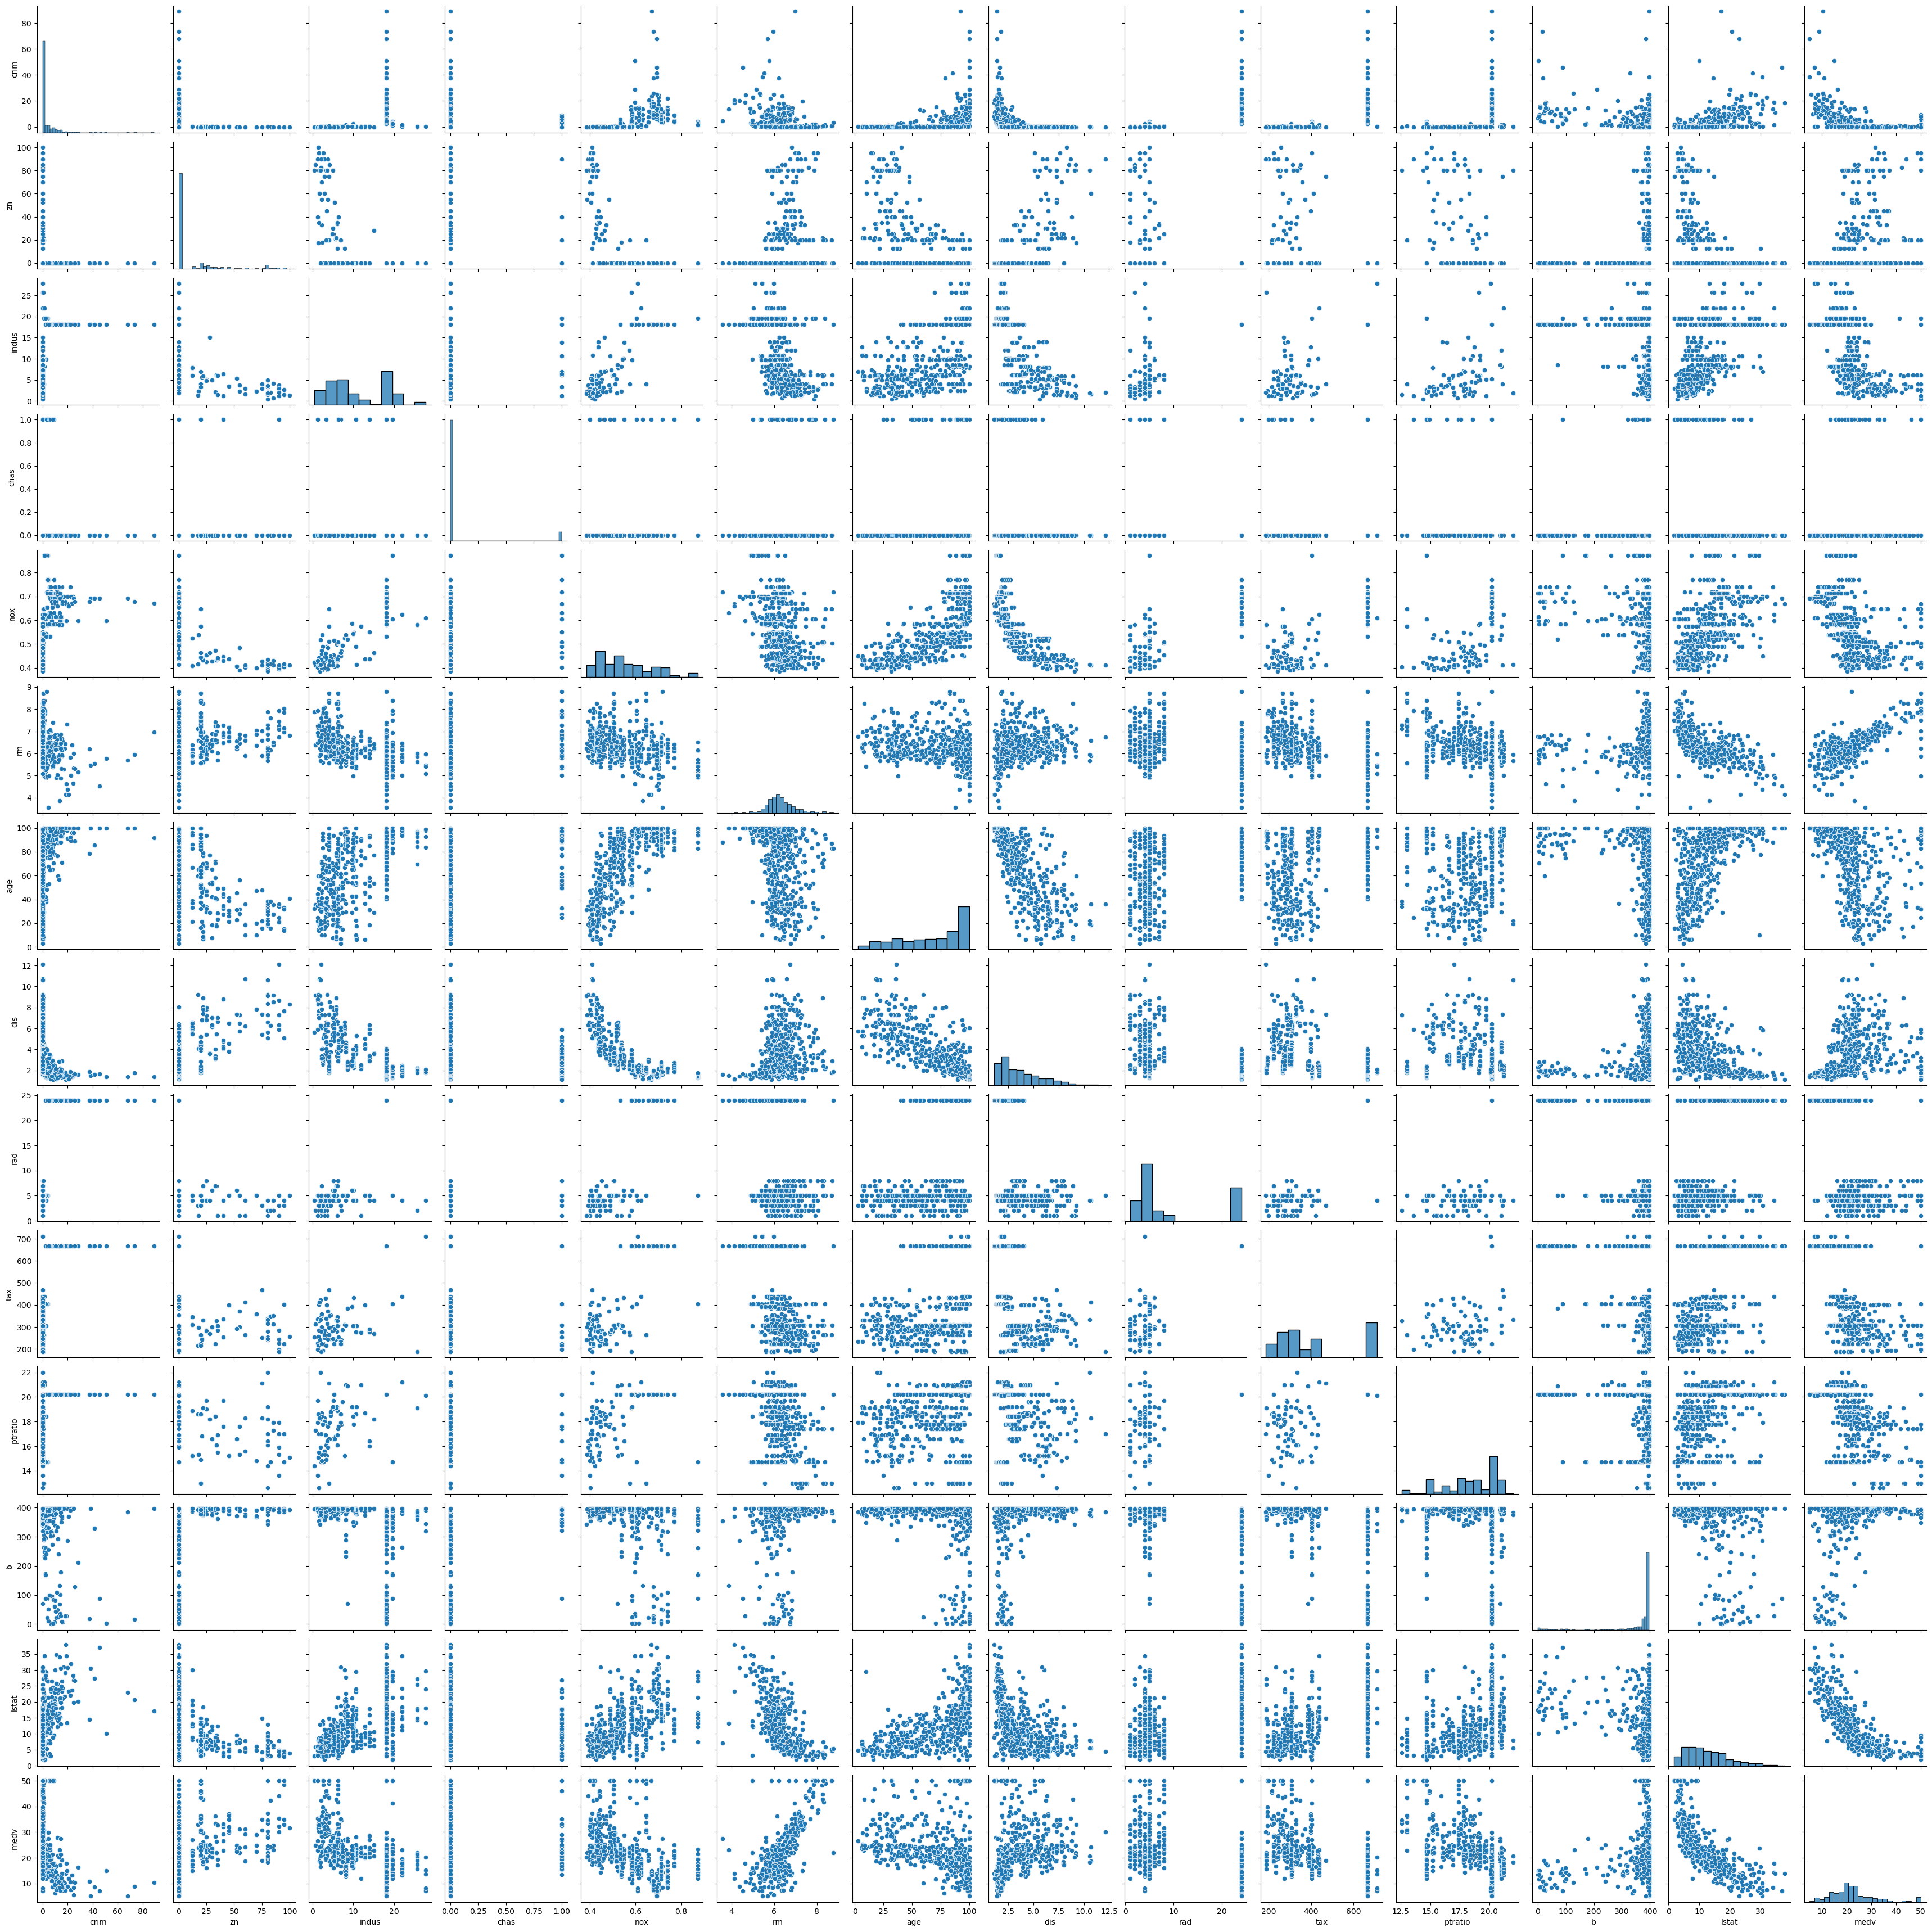

In [12]:
# Pairplot

sns.pairplot(df)

plt.show()

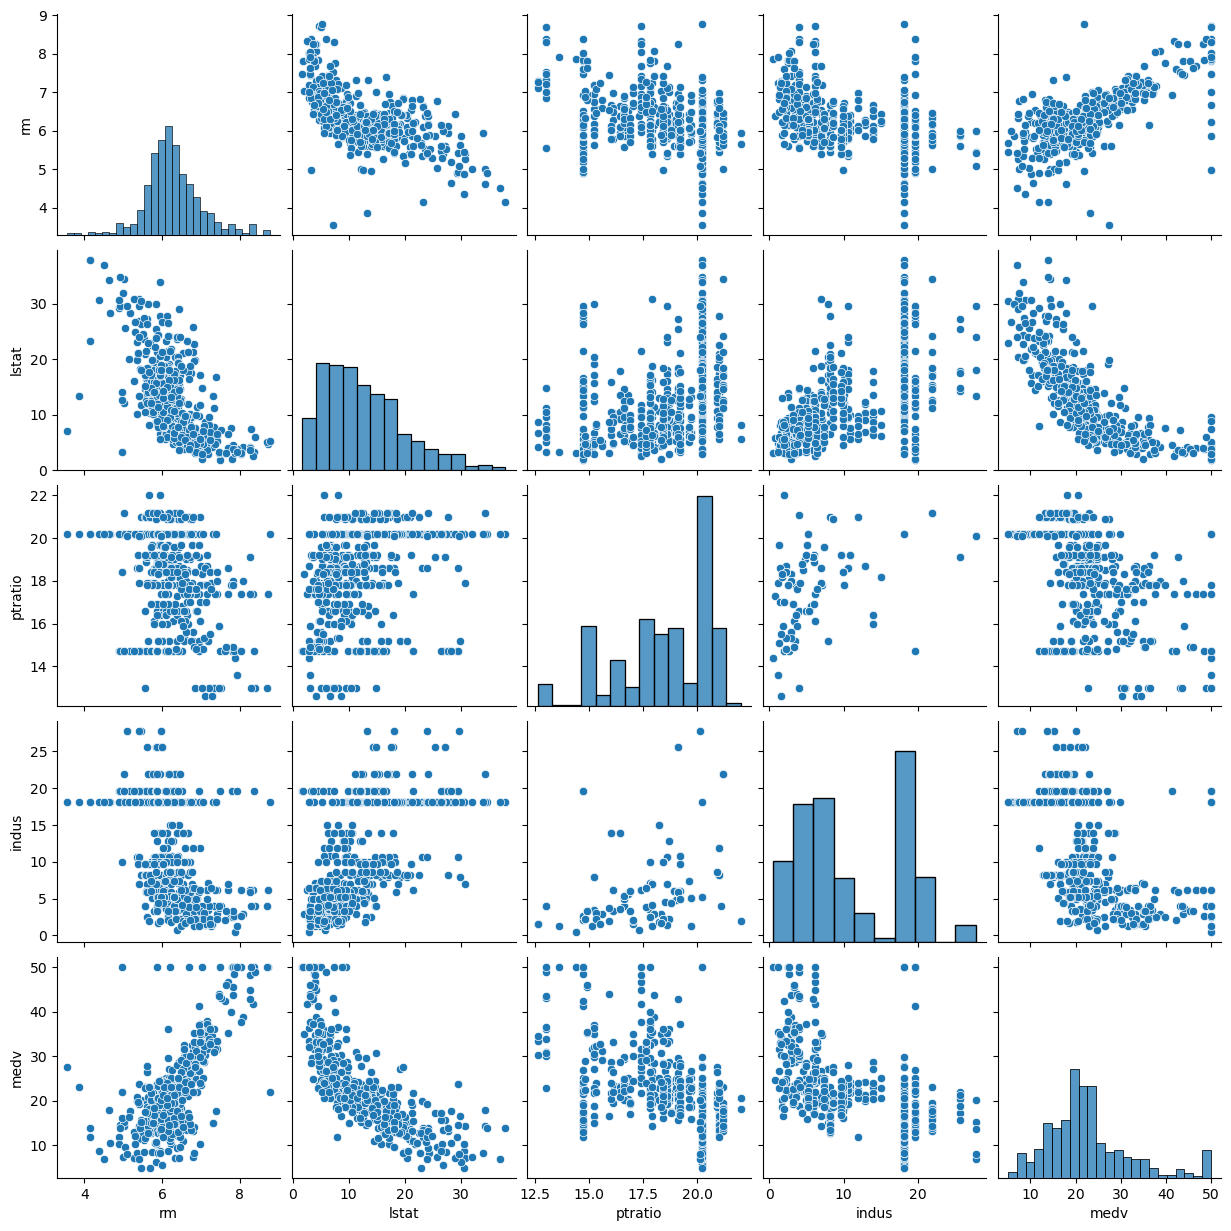

In [21]:
# Pairplot of selected important features

selected_features = ['rm', 'lstat', 'ptratio', 'indus', 'medv']

sns.pairplot(df[selected_features])
plt.show()

### Correlation Matrix

A correlation matrix shows the correlation coefficient between every pair of variables.

The values range from:

- +1 : Perfect Positive Correlation
- 0 : No Correlation
- -1 : Perfect Negative Correlation

In [15]:
# Correlation Matrix

correlation_matrix = df.corr()

correlation_matrix

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
crim,1.000000,-0.200469,0.406583,-0.055892,0.420972,-0.219247,0.352734,-0.379670,0.625505,0.582764,0.289946,-0.385064,0.455621,-0.388305
zn,-0.200469,1.000000,-0.533828,-0.042697,-0.516604,0.311991,-0.569537,0.664408,-0.311948,-0.314563,-0.391679,0.175520,-0.412995,0.360445
indus,0.406583,-0.533828,1.000000,0.062938,0.763651,-0.391676,0.644779,-0.708027,0.595129,0.720760,0.383248,-0.356977,0.603800,-0.483725
chas,-0.055892,-0.042697,0.062938,1.000000,0.091203,0.091251,0.086518,-0.099176,-0.007368,-0.035587,-0.121515,0.048788,-0.053929,0.175260
nox,0.420972,-0.516604,0.763651,0.091203,1.000000,-0.302188,0.731470,-0.769230,0.611441,0.668023,0.188933,-0.380051,0.590879,-0.427321
rm,-0.219247,0.311991,-0.391676,0.091251,-0.302188,1.000000,-0.240265,0.205246,-0.209847,-0.292048,-0.355501,0.128069,-0.613808,0.695360
age,0.352734,-0.569537,0.644779,0.086518,0.731470,-0.240265,1.000000,-0.747881,0.456022,0.506456,0.261515,-0.273534,0.602339,-0.376955
dis,-0.379670,0.664408,-0.708027,-0.099176,-0.769230,0.205246,-0.747881,1.000000,-0.494588,-0.534432,-0.232471,0.291512,-0.496996,0.249929
rad,0.625505,-0.311948,0.595129,-0.007368,0.611441,-0.209847,0.456022,-0.494588,1.000000,0.910228,0.464741,-0.444413,0.488676,-0.381626
tax,0.582764,-0.314563,0.720760,-0.035587,0.668023,-0.292048,0.506456,-0.534432,0.910228,1.000000,0.460853,-0.441808,0.543993,-0.468536


### Correlation Heatmap

A heatmap provides a visual representation of the correlation matrix. Darker colors indicate stronger positive or negative correlations.

This helps identify the features that are most strongly related to the target variable (MEDV).

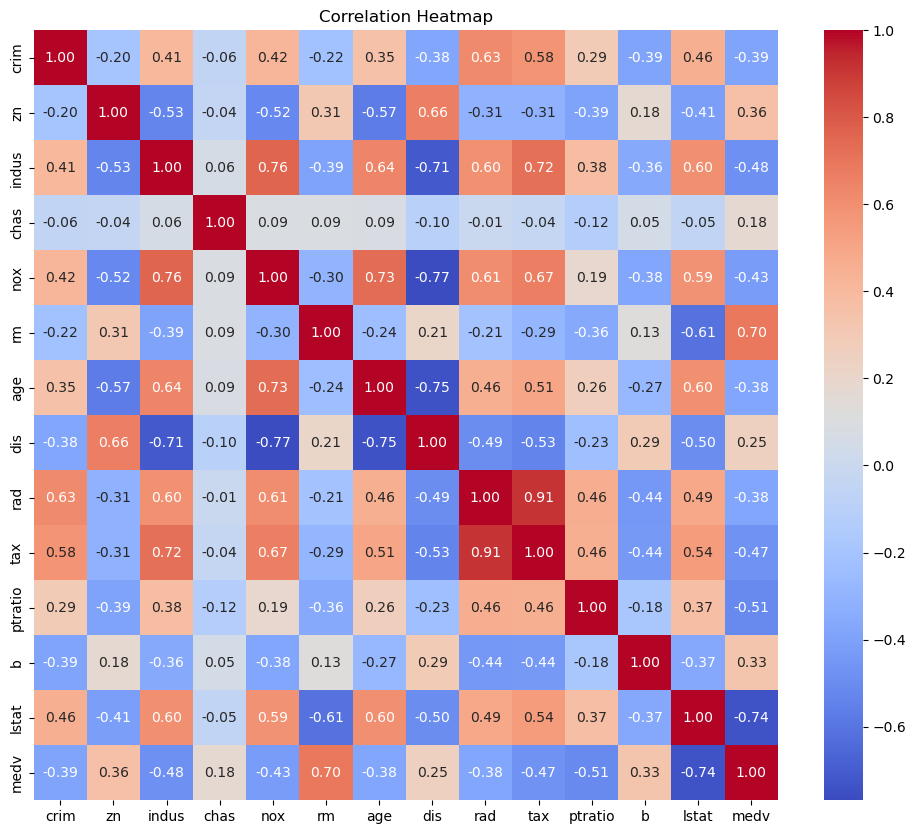

In [16]:
# Heatmap

plt.figure(figsize=(12,10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")

plt.show()

### Features Correlated with House Price (MEDV)

The following code displays the correlation of every feature with the target variable **MEDV**.

Positive values indicate that the feature increases with house price, while negative values indicate that the feature decreases as house price increases.

In [19]:
# Correlation with target variable

df.corr(numeric_only=True)['medv'].sort_values(ascending=False)

medv       1.000000
rm         0.695360
zn         0.360445
b          0.333461
dis        0.249929
chas       0.175260
age       -0.376955
rad       -0.381626
crim      -0.388305
nox       -0.427321
tax       -0.468536
indus     -0.483725
ptratio   -0.507787
lstat     -0.737663
Name: medv, dtype: float64

#### Observation :

From the correlation values, the following features are generally the most strongly related to **MEDV**:

- **RM** has a strong positive correlation with house price.
- **LSTAT** has a strong negative correlation with house price.
- **PTRATIO** has a negative correlation with house price.
- **TAX** and **INDUS** also show negative correlations with house price.
- **CRIM** has a negative correlation, indicating that higher crime rates are generally associated with lower house prices.

These features are useful predictors for building the Linear Regression model.

## Q8. Select Independent Variables (Features) and Dependent Variable (Target)

#### Answer :

In Machine Learning, the independent variables (features) are the input variables used to predict the target variable.

For this dataset:

- **Independent Variables (X):** All columns except **medv**
- **Dependent Variable (y):** **medv**, which represents the median house price.

In [22]:
# Independent variables
X = df.drop('medv', axis=1)

# Dependent variable
y = df['medv']

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (506, 13)
Target Shape: (506,)


## Q9. Split the Dataset into Training and Testing Sets (80% Training, 20% Testing)

#### Answer :

The dataset is divided into two parts:

- **Training Set (80%)**: Used to train the Linear Regression model.
- **Testing Set (20%)**: Used to evaluate the model's performance on unseen data.

The `train_test_split()` function from Scikit-learn is used for this purpose.

In [23]:
# Split the dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)

print("Training Target:", y_train.shape)
print("Testing Target:", y_test.shape)

Training Features: (404, 13)
Testing Features: (102, 13)
Training Target: (404,)
Testing Target: (102,)


## Q10. Train a Linear Regression Model

#### Answer :

A Linear Regression model is trained using the training dataset. After training, the model predicts house prices for the test dataset.

The performance of the model is evaluated using the following metrics:

- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² Score
- Adjusted R²

Finally, the Linear Regression equation is obtained, and the coefficients are interpreted.

In [24]:
# Create Linear Regression model

model = LinearRegression()

# Train the model

model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### Make Predictions

The trained model is used to predict house prices for the test dataset.

In [25]:
# Predict house prices

y_pred = model.predict(X_test)

### Model Evaluation

The performance of the model is evaluated using different regression metrics.

In [27]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import numpy as np

# MAE
mae = mean_absolute_error(y_test, y_pred)

# MSE
mse = mean_squared_error(y_test, y_pred)

# RMSE
rmse = np.sqrt(mse)

# R2 Score
r2 = r2_score(y_test, y_pred)

# Adjusted R2
n = X_test.shape[0]
p = X_test.shape[1]

adjusted_r2 = 1 - ((1-r2)*(n-1)/(n-p-1))

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)
print("Adjusted R²:", adjusted_r2)

Mean Absolute Error (MAE): 3.1890919658878594
Mean Squared Error (MSE): 24.291119474973655
Root Mean Squared Error (RMSE): 4.92860218266535
R² Score: 0.6687594935356301
Adjusted R²: 0.6198262368988482


### Linear Regression Equation

The Linear Regression equation is:

**Y = β₀ + β₁X₁ + β₂X₂ + ... + βₙXₙ**

where:

- **β₀** is the intercept.
- **β₁, β₂, ..., βₙ** are the coefficients of the independent variables.

In [29]:
print("Intercept:")
print(model.intercept_)

print("\nCoefficients:")
print(model.coef_)

Intercept:
30.24675099392328

Coefficients:
[-1.13055924e-01  3.01104641e-02  4.03807204e-02  2.78443820e+00
 -1.72026334e+01  4.43883520e+00 -6.29636221e-03 -1.44786537e+00
  2.62429736e-01 -1.06467863e-02 -9.15456240e-01  1.23513347e-02
 -5.08571424e-01]


### Model Coefficients

The following table shows the coefficient of each feature in the Linear Regression model.

In [31]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

coefficients

,Feature,Coefficient
0,crim,-0.113056
1,zn,0.030110
2,indus,0.040381
3,chas,2.784438
4,nox,-17.202633
5,rm,4.438835
6,age,-0.006296
7,dis,-1.447865
8,rad,0.262430
9,tax,-0.010647


### Interpretation of Coefficients

- A **positive coefficient** indicates that as the feature increases, the predicted house price tends to increase, while keeping all other variables constant.

- A **negative coefficient** indicates that as the feature increases, the predicted house price tends to decrease.

- Features with **larger absolute coefficient values** generally have a stronger influence on the predicted house price.

The exact interpretation depends on the coefficient values obtained after training the model.

## Conclusion

A Linear Regression model was successfully built to predict house prices using the Boston Housing dataset.

The dataset was explored through Exploratory Data Analysis (EDA), including pairplots and a correlation heatmap. The data was then split into training and testing sets, and a Linear Regression model was trained.

The model's performance was evaluated using MAE, MSE, RMSE, R² Score, and Adjusted R². The regression coefficients were examined to understand the influence of each feature on house prices.

Overall, this workflow demonstrates the complete process of building and evaluating a Linear Regression model for a real-world prediction problem.